In [1]:
from Bio import SeqIO
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
#defining dataset paths
DATA_DIR = "../data"

HUMAN_DIR = f"{DATA_DIR}/human"
DEN_DIR = f"{DATA_DIR}/denisovan"
NEA_DIR = f"{DATA_DIR}/neanderthal"

In [3]:
#loading FASTA

def load_fasta(path):

    sequences = []

    for record in SeqIO.parse(path, "fasta"):
        sequences.append(str(record.seq))

    return sequences

In [4]:
#loading one chromosome from human
human_chr1 = load_fasta(f"{HUMAN_DIR}/Homo_sapiens.GRCh38.dna.chromosome.1.fa")
#loading one chromosome from neanderthals
nea_chr1 = load_fasta(f"{NEA_DIR}/nea_chr1.fasta")
#loading one chromosome from denisovans
den_chr1 = load_fasta(f"{DEN_DIR}/den_chr1.fasta")


In [5]:
print("Human sequences:", len(human_chr1))
print("Denisovan sequences:", len(den_chr1))
print("Neanderthal sequences:", len(nea_chr1))

Human sequences: 1
Denisovan sequences: 109225
Neanderthal sequences: 3831


In [6]:
len(human_chr1[0])

248956422

In [7]:
len(den_chr1[4])

59

In [8]:
len(nea_chr1[0])

48

In [9]:
def get_length(sequences):
    return[len(s) for s in sequences]

In [10]:
human_lengths = get_length(human_chr1)
den_lengths = get_length(den_chr1)
nea_lengths = get_length(nea_chr1)


print("Denisovan length range:", min(den_lengths), max(den_lengths))
print("Neanderthal length range:", min(nea_lengths), max(nea_lengths))
print("Human length range:", min(human_lengths), max(human_lengths))




Denisovan length range: 35 179
Neanderthal length range: 25 85
Human length range: 248956422 248956422


In [11]:
def print_stats(name, arr):
    print(f"{name}")
    print("min:", np.min(arr))
    print("max:", np.max(arr))
    print("mean:", np.mean(arr))
    print("median:", np.median(arr))
    print()

print_stats("Denisovan", den_lengths)
print_stats("Neanderthal", nea_lengths)
print_stats("Human", human_lengths)

Denisovan
min: 35
max: 179
mean: 56.52969558251316
median: 46.0

Neanderthal
min: 25
max: 85
mean: 49.71626207256591
median: 47.0

Human
min: 248956422
max: 248956422
mean: 248956422.0
median: 248956422.0



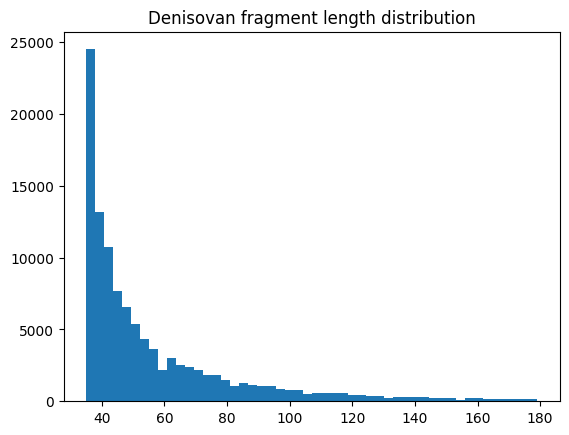

In [12]:
plt.hist(den_lengths, bins=50)
plt.title("Denisovan fragment length distribution")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

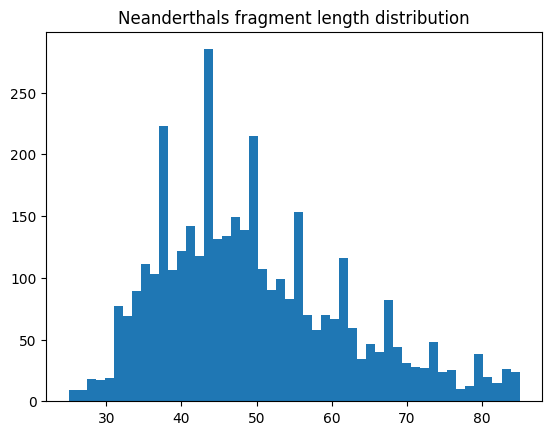

In [13]:
plt.hist(nea_lengths, bins=50)
plt.title("Neanderthals fragment length distribution")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

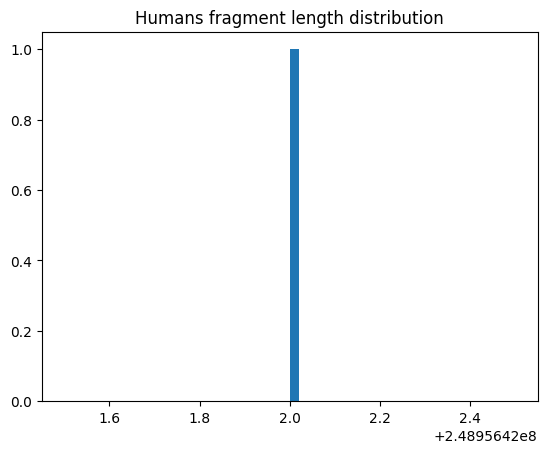

In [14]:
plt.hist(human_lengths, bins=50)
plt.title("Humans fragment length distribution")
plt.show

In [21]:
#this function will check the AGTCN frequencies
def base_composition(seqs):
    counts = Counter()
    for s in seqs:
        counts.update(s)
    total = sum(counts.values())
    for base in counts:
        print(base,counts[base]/total)

print("Denisovan compositoon")
base_composition(den_chr1[:10000])

Denisovan compositoon
A 0.3004554274791474
G 0.18655149443929564
T 0.2943607362140871
C 0.2185997596153846
N 3.2582252085264136e-05


In [22]:
print("Neanderthal composition")
base_composition(nea_chr1[:10000])

Neanderthal composition
T 0.2554826921764332
A 0.25713130634296427
C 0.24577476990281577
G 0.24161123157778677


In [23]:
print("Human composition")
base_composition([human_chr1[0][:100000]])

Human composition
N 0.1
T 0.25058
A 0.26735
C 0.19924
G 0.18283


In [24]:
# now we are doing a fucntion that checks
#the amount of n in each of this
#since in our previous analysis we saw that human genomes has a lot of 
#n values so we need to check it too 
def n_fraction(seqs):
    total = 0
    ncount = 0
    for s in seqs:
        total += len(s)
        ncount += s.count("N")
    print("N fraction:", ncount/total)

In [25]:
print("Denisovan")
n_fraction(den_chr1[:10000])

print("Neanderthal")
n_fraction(nea_chr1[:10000])

print("Human")
n_fraction([human_chr1[0][:100000]])

Denisovan
N fraction: 3.2582252085264136e-05
Neanderthal
N fraction: 0.0
Human
N fraction: 0.1
